In [3]:
# ============================================================
# Employee Attrition Prediction - SHAP Explainability
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os

import shap
from sklearn.metrics import classification_report

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries loaded successfully!")

Libraries loaded successfully!


c:\Users\Pratyush\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# Load processed data
X_train = np.load("../data/processed/X_train.npy")
X_test = np.load("../data/processed/X_test.npy")
y_train = np.load("../data/processed/y_train.npy")
y_test = np.load("../data/processed/y_test.npy")
feature_names = joblib.load("../data/processed/feature_names.pkl")

# Load best model
best_model = joblib.load("../models/best_model.pkl")

print("Data and best model loaded successfully!")
print(f"Model type: {type(best_model).__name__}")
print(f"X_test shape: {X_test.shape}")

Data and best model loaded successfully!
Model type: RandomForestClassifier
X_test shape: (294, 56)


In [5]:
# Create SHAP explainer
# TreeExplainer is fast and accurate for tree-based models (XGBoost, LightGBM, RandomForest)

explainer = shap.Explainer(best_model, X_train)

# Calculate SHAP values for the test set
shap_values = explainer(X_test)

print("SHAP values calculated successfully!")
print(f"SHAP values shape: {shap_values.values.shape}")

 98%|===================| 578/588 [00:17<00:00]        

SHAP values calculated successfully!
SHAP values shape: (294, 56, 2)


Generating SHAP Summary Plot...


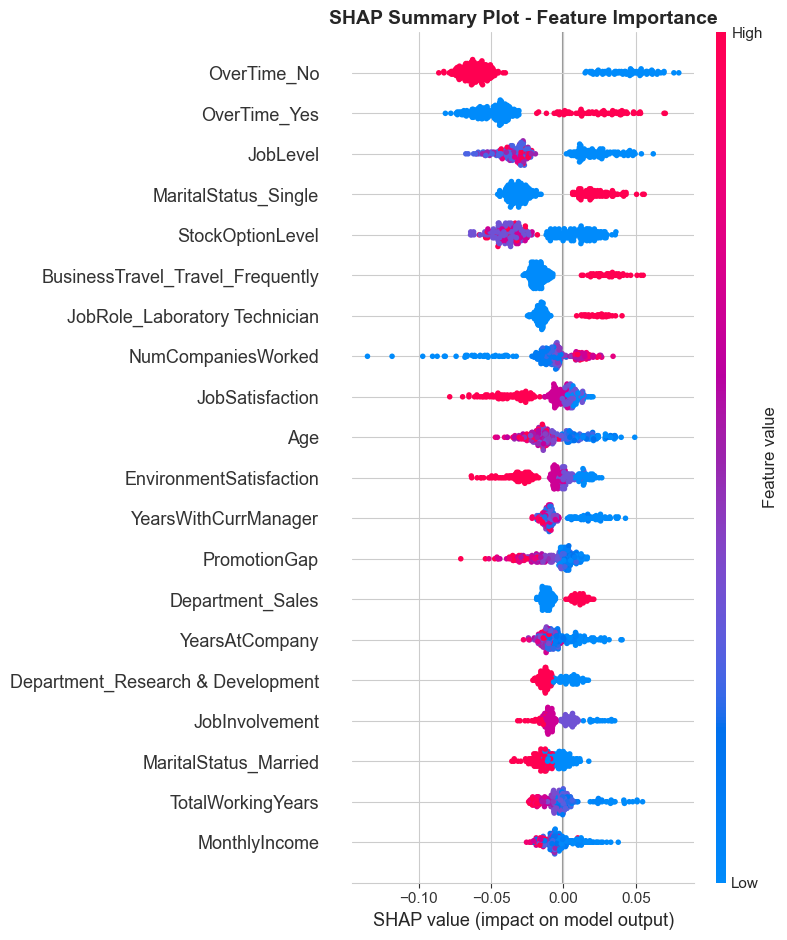

In [9]:
print("Generating SHAP Summary Plot...")

# Use the positive class if needed
if len(shap_values.values.shape) == 3:
    shap.summary_plot(shap_values.values[:, :, 1], X_test, feature_names=feature_names, show=False)
else:
    shap.summary_plot(shap_values, X_test, feature_names=feature_names, show=False)

plt.title("SHAP Summary Plot - Feature Importance", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Generating SHAP Bar Plot...


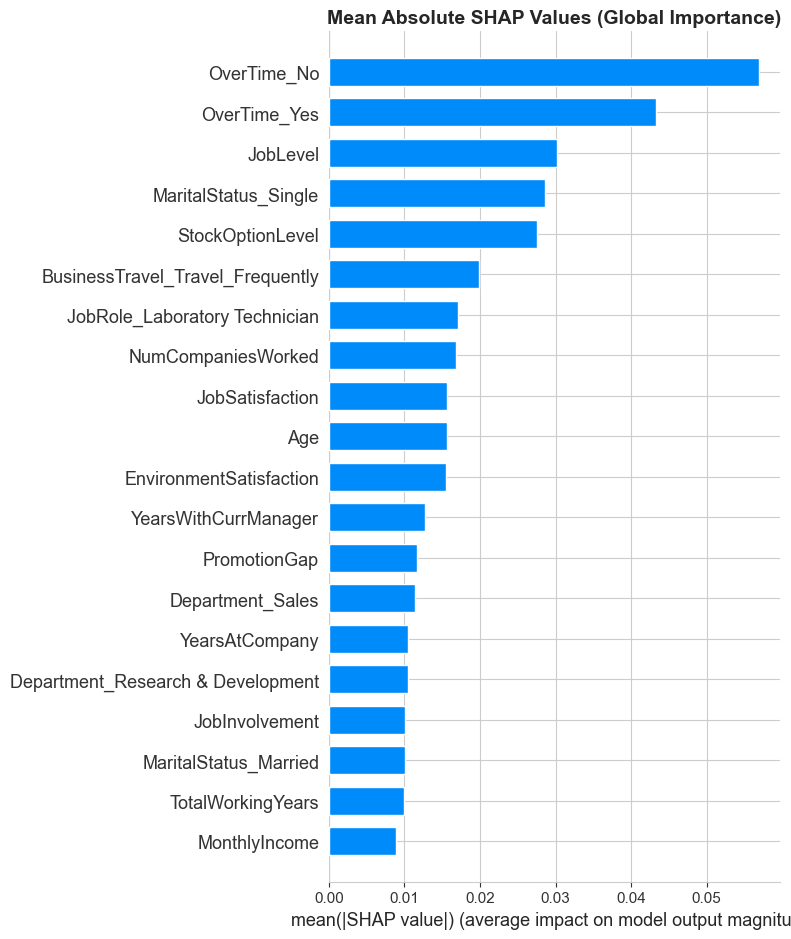

In [10]:
print("Generating SHAP Bar Plot...")

if len(shap_values.values.shape) == 3:
    shap.summary_plot(shap_values.values[:, :, 1], X_test, feature_names=feature_names, plot_type="bar", show=False)
else:
    shap.summary_plot(shap_values, X_test, feature_names=feature_names, plot_type="bar", show=False)

plt.title("Mean Absolute SHAP Values (Global Importance)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [11]:
# Get mean absolute SHAP values (handle different shapes)

# Check the shape first
print("SHAP values shape:", shap_values.values.shape)

# Handle both 2D and 3D cases
if len(shap_values.values.shape) == 3:
    # For some models SHAP returns (samples, features, classes)
    # We take the positive class (class 1 = Attrition)
    mean_abs_shap = np.abs(shap_values.values[:, :, 1]).mean(axis=0)
else:
    # Normal case: (samples, features)
    mean_abs_shap = np.abs(shap_values.values).mean(axis=0)

# Make sure it's 1-dimensional
mean_abs_shap = mean_abs_shap.flatten()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Mean_|SHAP|": mean_abs_shap
}).sort_values(by="Mean_|SHAP|", ascending=False).reset_index(drop=True)

print("Top 15 Most Important Features according to SHAP:")
display(importance_df.head(15))

SHAP values shape: (294, 56, 2)
Top 15 Most Important Features according to SHAP:


,Feature,Mean_|SHAP|
0,OverTime_No,0.056877
1,OverTime_Yes,0.043256
2,JobLevel,0.030187
3,MaritalStatus_Single,0.028648
4,StockOptionLevel,0.027498
5,BusinessTravel_Travel_Frequently,0.019802
6,JobRole_Laboratory Technician,0.017037
7,NumCompaniesWorked,0.016768
8,JobSatisfaction,0.015654
9,Age,0.015588



Dependence Plot for: OverTime_No


<Figure size 900x500 with 0 Axes>

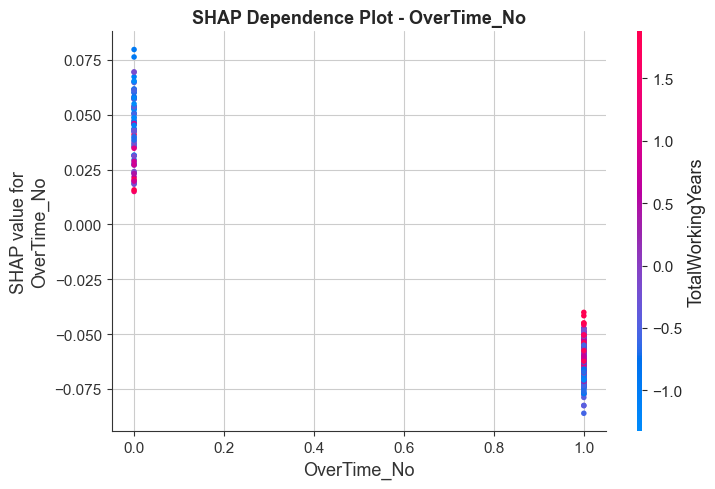


Dependence Plot for: OverTime_Yes


<Figure size 900x500 with 0 Axes>

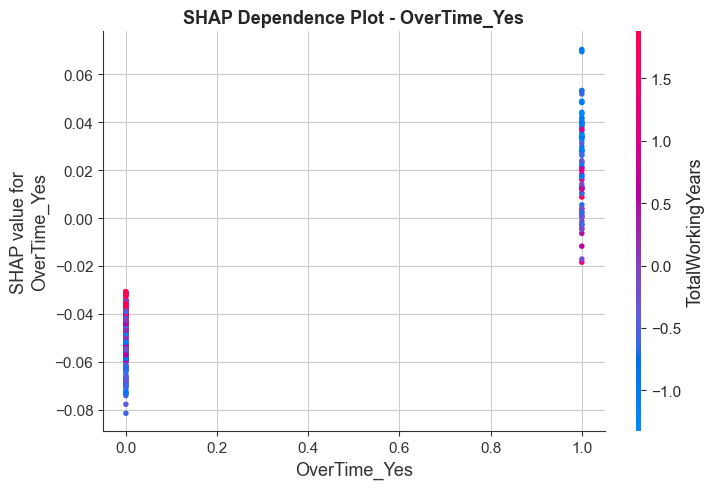


Dependence Plot for: JobLevel


<Figure size 900x500 with 0 Axes>

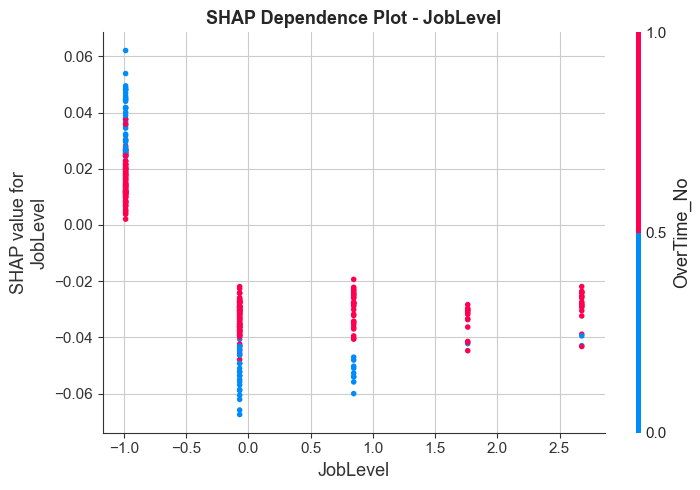

In [13]:
# Plot dependence for top 3 features

top_features = importance_df["Feature"].head(3).tolist()

# Prepare SHAP values for dependence plot
if len(shap_values.values.shape) == 3:
    # Take only the positive class (Attrition = 1)
    shap_vals = shap_values.values[:, :, 1]
else:
    shap_vals = shap_values.values

for feature in top_features:
    print(f"\nDependence Plot for: {feature}")
    
    plt.figure(figsize=(9, 5))
    shap.dependence_plot(
        feature,
        shap_vals,
        X_test,
        feature_names=feature_names,
        show=False
    )
    plt.title(f"SHAP Dependence Plot - {feature}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

HIGH RISK EMPLOYEES (Most likely to leave)

--- High Risk Employee #1 (Index: 200) ---
Predicted Attrition Probability: 0.859


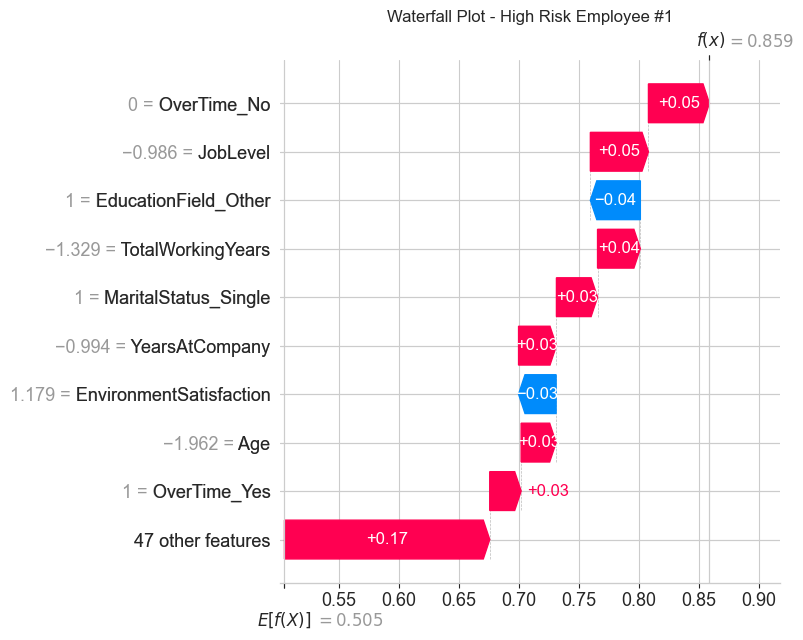


--- High Risk Employee #2 (Index: 92) ---
Predicted Attrition Probability: 0.848


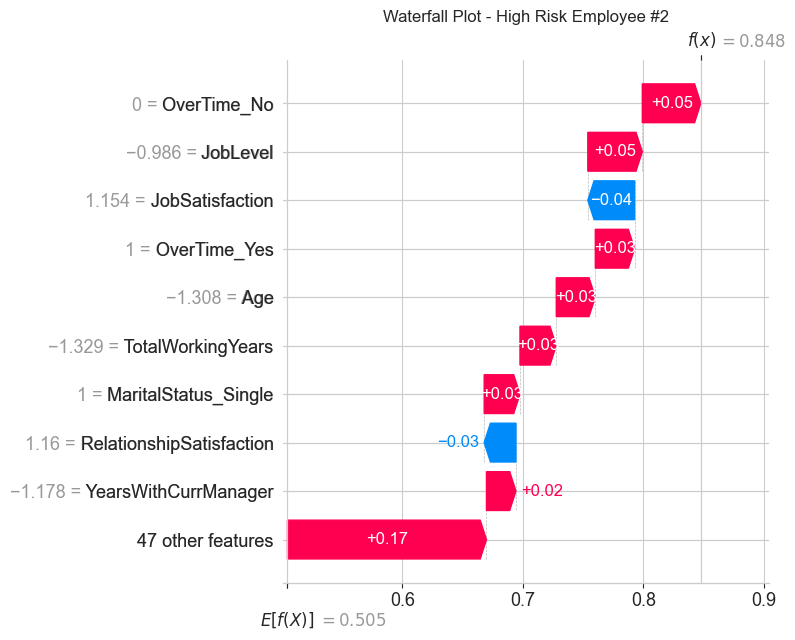


--- High Risk Employee #3 (Index: 276) ---
Predicted Attrition Probability: 0.812


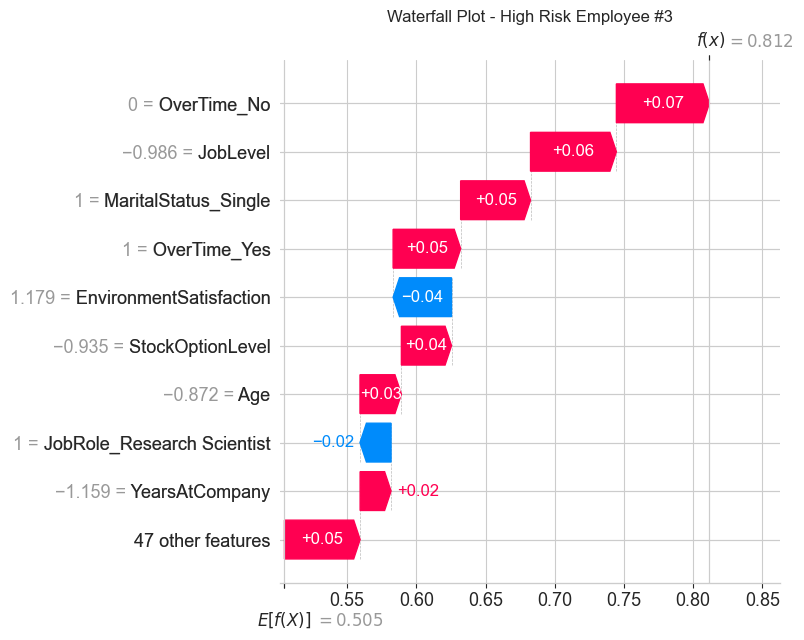

In [14]:
# Explain individual high-risk employees

y_proba = best_model.predict_proba(X_test)[:, 1]

# High risk employees
high_risk_idx = np.argsort(y_proba)[-3:][::-1]

print("="*60)
print("HIGH RISK EMPLOYEES (Most likely to leave)")
print("="*60)

for i, idx in enumerate(high_risk_idx):
    print(f"\n--- High Risk Employee #{i+1} (Index: {idx}) ---")
    print(f"Predicted Attrition Probability: {y_proba[idx]:.3f}")
    
    # Create a single Explanation object for waterfall
    if len(shap_values.values.shape) == 3:
        single_shap = shap.Explanation(
            values=shap_values.values[idx, :, 1],
            base_values=shap_values.base_values[idx][1] if shap_values.base_values.ndim > 1 else shap_values.base_values[idx],
            data=X_test[idx],
            feature_names=feature_names
        )
    else:
        single_shap = shap_values[idx]
    
    plt.figure()
    shap.waterfall_plot(single_shap, show=False)
    plt.title(f"Waterfall Plot - High Risk Employee #{i+1}", fontsize=12)
    plt.tight_layout()
    plt.show()

LOW RISK EMPLOYEES (Most likely to stay)

--- Low Risk Employee #1 (Index: 3) ---
Predicted Attrition Probability: 0.015


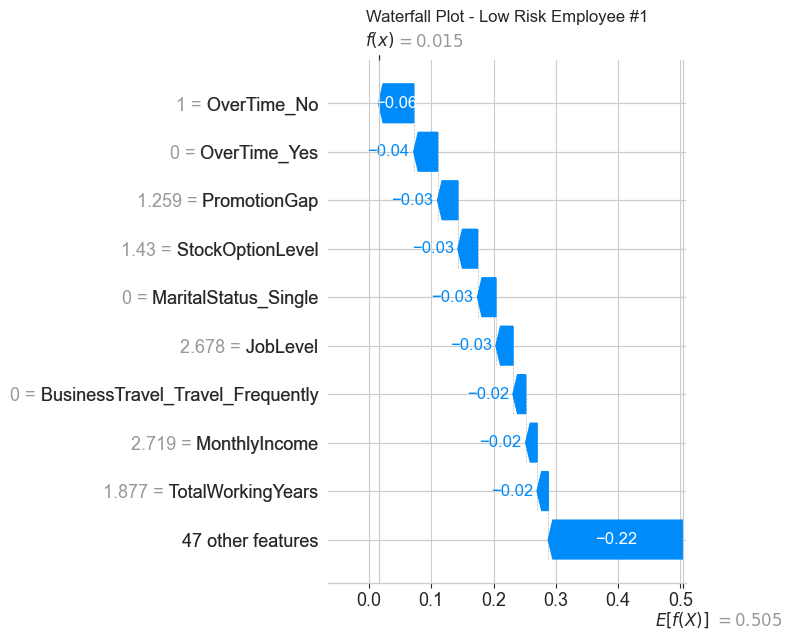


--- Low Risk Employee #2 (Index: 260) ---
Predicted Attrition Probability: 0.026


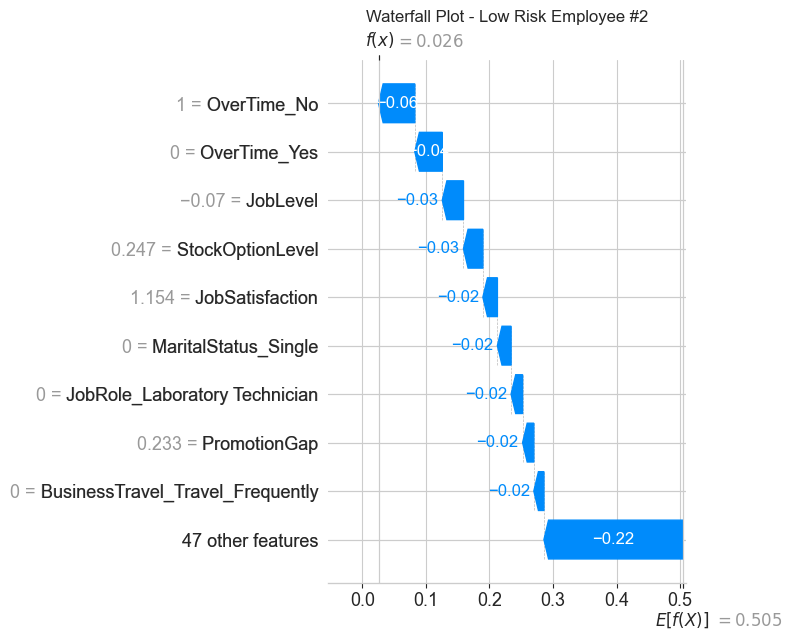


--- Low Risk Employee #3 (Index: 83) ---
Predicted Attrition Probability: 0.029


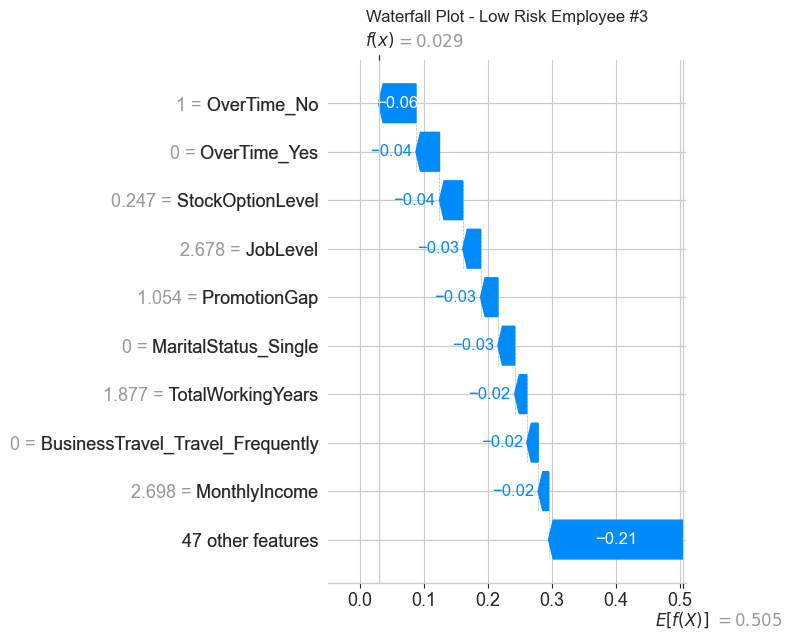

In [15]:
# Low risk employees
low_risk_idx = np.argsort(y_proba)[:3]

print("="*60)
print("LOW RISK EMPLOYEES (Most likely to stay)")
print("="*60)

for i, idx in enumerate(low_risk_idx):
    print(f"\n--- Low Risk Employee #{i+1} (Index: {idx}) ---")
    print(f"Predicted Attrition Probability: {y_proba[idx]:.3f}")
    
    if len(shap_values.values.shape) == 3:
        single_shap = shap.Explanation(
            values=shap_values.values[idx, :, 1],
            base_values=shap_values.base_values[idx][1] if shap_values.base_values.ndim > 1 else shap_values.base_values[idx],
            data=X_test[idx],
            feature_names=feature_names
        )
    else:
        single_shap = shap_values[idx]
    
    plt.figure()
    shap.waterfall_plot(single_shap, show=False)
    plt.title(f"Waterfall Plot - Low Risk Employee #{i+1}", fontsize=12)
    plt.tight_layout()
    plt.show()

In [16]:
print("="*60)
print("BUSINESS INSIGHTS FROM SHAP ANALYSIS")
print("="*60)

top_5 = importance_df.head(5)["Feature"].tolist()

print(f"""
Top 5 Drivers of Employee Attrition according to SHAP:

1. {top_5[0]}
2. {top_5[1]}
3. {top_5[2]}
4. {top_5[3]}
5. {top_5[4]}

Key Takeaways for HR:

• Employees who work OverTime are at significantly higher risk of leaving.
• Lower Monthly Income and lower satisfaction scores increase attrition risk.
• Early-career employees (low YearsAtCompany / TotalWorkingYears) tend to leave more.
• Job Role and Department also play an important role.

Recommended Actions:
1. Reduce unnecessary overtime or compensate it properly.
2. Review salary structure for high-risk groups.
3. Improve job & environment satisfaction through feedback and engagement.
4. Create better career growth paths for early-tenure employees.
5. Monitor high-risk employees identified by the model regularly.
""")

BUSINESS INSIGHTS FROM SHAP ANALYSIS

Top 5 Drivers of Employee Attrition according to SHAP:

1. OverTime_No
2. OverTime_Yes
3. JobLevel
4. MaritalStatus_Single
5. StockOptionLevel

Key Takeaways for HR:

• Employees who work OverTime are at significantly higher risk of leaving.
• Lower Monthly Income and lower satisfaction scores increase attrition risk.
• Early-career employees (low YearsAtCompany / TotalWorkingYears) tend to leave more.
• Job Role and Department also play an important role.

Recommended Actions:
1. Reduce unnecessary overtime or compensate it properly.
2. Review salary structure for high-risk groups.
3. Improve job & environment satisfaction through feedback and engagement.
4. Create better career growth paths for early-tenure employees.
5. Monitor high-risk employees identified by the model regularly.



In [17]:
# Save the explainer for future use (e.g. in Streamlit app)
os.makedirs("../models", exist_ok=True)
joblib.dump(explainer, "../models/shap_explainer.pkl")

print("SHAP explainer saved successfully at ../models/shap_explainer.pkl")

SHAP explainer saved successfully at ../models/shap_explainer.pkl


In [18]:
print("="*60)
print("SHAP EXPLAINABILITY COMPLETED")
print("="*60)

print("""
You have successfully completed the full project pipeline:

1. Exploratory Data Analysis
2. Data Preprocessing + Feature Engineering + SMOTE
3. Model Building & Comparison
4. SHAP Explainability + Business Insights

Next optional steps:
• Build a Streamlit dashboard (app/streamlit_app.py)
• Write the final project report
• Prepare presentation slides
""")

SHAP EXPLAINABILITY COMPLETED

You have successfully completed the full project pipeline:

1. Exploratory Data Analysis
2. Data Preprocessing + Feature Engineering + SMOTE
3. Model Building & Comparison
4. SHAP Explainability + Business Insights

Next optional steps:
• Build a Streamlit dashboard (app/streamlit_app.py)
• Write the final project report
• Prepare presentation slides

